# Simple 2D CNN with ocean mask and season

**Author:** Eli Holmes (NOAA), Yifei Hang (UW Varanasi intern 2024), Jiarui Yu (UW Varanasi intern 2023)

[![Colab Badge](https://img.shields.io/badge/Open_in_Colab-blue?style=for-the-badge)][colab-link]
<a href="javascript:void(0);" onclick="openJupyterWidget('https://github.com/ocean-satellite-tools/mind-the-chl-gap/blob/main/book/notebooks/CNN_2D.ipynb');">
    <img src="https://img.shields.io/badge/Open_in_JupyterHub-orange?style=for-the-badge" alt="JupyterHub Badge">
</a> [![Download Badge](https://img.shields.io/badge/Download-grey?style=for-the-badge)][download-link]

[download-link]: https://ocean-satellite-tools.github.io/mind-the-chl-gap/_static/CNN_2D.ipynb
[colab-link]: https://colab.research.google.com/github/ocean-satellite-tools/mind-the-chl-gap/blob/main/book/notebooks/CNN_2D.ipynb
[jupyter-link]: https://nmfs-openscapes.2i2c.cloud/hub/user-redirect/lab?fromURL=https://raw.githubusercontent.com/ocean-satellite-tools/mind-the-chl-gap/main/book/notebooks/CNN_2D.ipynb

This is a basic 2D CNN model where we are predicting a variable using reponse variables, in this case SST, salinity, and season. 

$$
\hat{y} \sim f(sst, so, season, location)
$$

We include a land/ocean mask as an input (training variable) so the model can learn the land/ocean boundary and so we can use a custom loss function to tell the model not to train on the y (CHL) that is over land. Those are not real data. We include season so that the model can use different feature weightings for different times of the year. We include location (using spectral decomposition of lat/lot) so the model can learn location specific relationships.

The CNN can learn features like fronts and swirls that might be important for predicting CHL at a pixel. We will compare to a boosted regression tree with the same predictors but that doesn't use the local spatial information around the pixel we are trying to predict.

**This notebook creates the training data as NumPy arrays. The data needs to be able to be loaded fully into memory. See the xbatcher notebook for working with larger than memory data.**

::: {.callout-note}
# Run this with GPU

Fitting this model will be quite slow with CPU. You can run in Colab if you don't have GPU access. Click the "Open in Colab" button above. Sign in with a Google Account. You get ca 100 hours of compute a month for free.

To get GPU in Colab, go to Edit > Notebook Settings  and select GPU. Then uncomment the `!pip` line below to install the needed libraries.
:::

::: {.callout-note}
# Running in JupyterHub

Although you can run this tutorial on CPU (default for JupyterHub), it will be much faster on GPU. We used the image `quay.io/pangeo/ml-notebook:2025.05.22` for running the notebook. This includes the tensorflow package.

If on the JupyterHub, shutdown kernels before you start in order to not run out of memory.

Kernel > Shutdown All Kernels
:::


## Overview of the steps

1. Load data
2. Prepare training, test, and validation data. Normalize the training data and deal with NAs in the data.
3. Set up model
4. Fit model
5. Make predictions

### Variables in the model

| Feature        | Spatial Variation       | Temporal Variation | Notes                             |
|----------------|-------------------------|--------------------|-----------------------------------|
| `sst`, `so`        | ✅ Varies by lat/lon     | ✅ Varies by time   | Numeric, normalize                |
| `sin_time`, `cos_time` | ❌ Same across lat/lon   | ✅ Varies by time   | Cyclical, **do not normalize** |
| `x_geo`,`y_geo`, `z_geo` | ✅ Varies by lat/lon   |❌ Static   | -1 to 1, **do not normalize**    |
| `ocean_mask`   | ✅ Varies by lat/lon     | ❌ Static           | Binary (0=land, 1=ocean), **do not normalize** |
| `y` (log CHL) | ✅ Varies by lat/lon     | ✅ Varies by time   | Numeric, maybe normalize  |


- **`sst` and `so`**: These are our core spatial-temporal features. The CNN will learn spatial filters to extract patterns over ocean and time.
  
- **`sin_time` and `cos_time`**: These introduce seasonality into our model. The CNN can learn seasonally dependent patterns, e.g., chlorophyll blooms in spring. The `sin_time` and `cos_time` features are designed to represent **seasonality** using a **cyclical encoding**. Normalizing these features (e.g., to mean 0, std 1) would **distort their circular geometry** and defeat their intended purpose.

- **`ocean_mask`**: This acts like a location-aware binary filter. It tells the CNN which pixels are land (0) vs ocean (1). The mask is used in a custom loss function which helps avoid learning patterns over invalid/land areas, but it is also used in the categorical variables passed to the model which helps it learn the effect of coastlines.

- **`y` (response)**: The model trains on this. We have logged it and it is roughly centered near 0. We need to evaluate whether our response has areas with much much higher variance than other areas. If so, we need to do some spatial normalization so our model doesn't only learn the high variance areas.

### Modifying the notebook to fit your own 2D CNN

* Data: an xarray Dataset with your response variable and explanatory variables. 
* `num_var`: the variables which will be normalized
* `cat_var`: the variables which will be left as is
* `mask`: The model will not be trained on the data under the mask
* functions: in `model_utils.py`
  
Variables can be 2D (not time-varying) or 3D (time-varying). They can be numerical (will be normalized) or categorical (will not be normalized). Note, categorical can be numerical. Difference is what will be normalized and what will not.


## Load the libraries

In [3]:
# Uncomment this line and run if you are in Colab; leave in the !. That is part of the cmd
# !pip install zarr gcsfs --quiet

In [1]:
# --- Core data handling libraries ---
import xarray as xr       # for working with labeled multi-dimensional arrays
import numpy as np        # for numerical operations on arrays

# --- Plotting ---
import matplotlib.pyplot as plt  # for creating plots

In [62]:
%%capture
# Our custom functions in file model_utils.py
# import model_utils as mu
import importlib
import model_utils as mu
importlib.reload(mu);

In [6]:
%%capture 
# --- TensorFlow libraries ---
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # suppress TensorFlow log spam (0=all, 3=only errors)

import tensorflow as tf  # main deep learning framework

# --- Keras (part of TensorFlow): building and training neural networks ---
from keras.models import Sequential          # lets us stack layers in a simple linear model
from keras.layers import Conv2D              # 2D convolution layer — finds spatial patterns in image-like data
from keras.layers import BatchNormalization  # stabilizes and speeds up training by normalizing activations
from keras.layers import Dropout             # randomly "drops" neurons during training to reduce overfitting
from keras.callbacks import EarlyStopping    # stops training early if validation loss doesn't improve

In [7]:
# Are we on GPU
print("GPU device:", tf.test.gpu_device_name() or "No GPU")

GPU device: /device:GPU:0


2025-10-16 16:13:56.099622: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2021] Created device /device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:1e.0, compute capability: 7.5


## Load data

The code to prepare the data is in `Data_Prep_CNN.ipynb`. The resulting Zarr was uploaded to a Google storage bucket. The Zarr is opened with `xarray` to create a dataset. The dataset goes from 1997 to 2022, however there is no salinity data after 2020.

### `open_dataset` versus `open_zarr`

The data in the Google Object Storage is a chunked Zarr file. It has files that are chunks of 100 days of data. When we go to get data we will get these files. How we load our data will determine if our xarray dataset "knows" about the chunks and this will make a big difference to speed and memory usage. 

`open_dataset` will load our data but it won't be dask arrays. So when we do computations, the dask machinary to do chunked processing will not be triggered. Effectively all the needed data (in this case 2020) will be loaded into memory. You will see that memory usage is high in this example. This is ok if all the training data can fit into memory. This will be the fastest approach. For this notebook, we will load all the training data into memory. See the `CNN_xbatcher` notebook for an approach for larger than memory training data.

In [91]:
# load full dataset 1997 to 2022 from Google bucket
dataset = xr.open_dataset(
    "gcs://nmfs_odp_nwfsc/CB/mind_the_chl_gap/cnn_tutorial",
    engine="zarr",
    backend_kwargs={"storage_options": {"token": "anon"}},
    consolidated=True
)
dataset

<xarray.Dataset> Size: 5GB
Dimensions:     (time: 9207, lat: 149, lon: 181)
Coordinates:
  * lat         (lat) float32 596B 32.0 31.75 31.5 31.25 ... -4.5 -4.75 -5.0
  * lon         (lon) float32 724B 45.0 45.25 45.5 45.75 ... 89.5 89.75 90.0
  * time        (time) datetime64[ns] 74kB 1997-10-01 1997-10-02 ... 2022-12-31
Data variables:
    cos_time    (time, lat, lon) float32 993MB ...
    ocean_mask  (lat, lon) float32 108kB ...
    sin_time    (time, lat, lon) float32 993MB ...
    so          (time, lat, lon) float32 993MB ...
    sst         (time, lat, lon) float32 993MB ...
    topo        (lat, lon) float32 108kB ...
    y           (time, lat, lon) float32 993MB ...

In [9]:
# the data are numpy arrays when loaded with open_dataset
for name, v in dataset.data_vars.items():
    is_dask = v.chunks is not None
    print(f"{name:20s} dask={is_dask}  chunks={v.chunks}")

cos_time             dask=False  chunks=None
ocean_mask           dask=False  chunks=None
sin_time             dask=False  chunks=None
so                   dask=False  chunks=None
sst                  dask=False  chunks=None
topo                 dask=False  chunks=None
y                    dask=False  chunks=None


So y has some days with too many NaN. We will remove those days.

## Process the data for training and testing

- Get the year(s) we want for training
- Remove the days with too many NaNs (> 5 percent) in response or explanatory variables
- Split data randomly into train, validate, and test pools
- Normalize the numerical predictor variables (SST and salinity)
- Replace NaNs with 0.
- Return stacked Numpy arrays

We need to normalize (mean zero, variance of 1) our numerical input variables but we need to compute the normalization metrics (`X_mean` and `X_std`) from the training data only. Otherwise we would have "data leakage"; information from the data we are predicting (not using for training) is used in testing or validation.

This function is stored in `model_utils.py` and loaded with `import model_utils as mu`. If you are running this notebook in your own directory, you will need to save the code at the bottom of this notebook as `model_utils.py` in the same directory as where you have this notebook.

In [22]:
help(mu.time_series_split)

Help on function time_series_split in module model_utils:

time_series_split(data: xarray.core.dataset.Dataset, num_var, cat_var=None, split_ratio=(0.7, 0.2, 0.1), seed=42, X_mean=None, X_std=None, y_var='y', years=None, cast_float32=True, contiguous_splits=False, return_full=False, nan_max_frac=0.05, verbose=False)
    Pure-NumPy splitter/normalizer for xarray Dataset (NumPy-backed).
    Splits time indices randomly into train/val/test. Replaces NaNs with 0s.
    Normalizes numerical variables only, using either provided or training-set mean/std.
    Removes days with too many NaNs (>

    Parameters:
      data: xarray dataset with 'time' dimension
      num_var: list of numerical variable names (to normalize)
      cat_var: list of categorical variable names (no normalization)
      y_var: name of response variable in data.
      split_ratio: tuple (train, val, test), must sum to 1.0
      seed: random seed
      nan_max_frac: maximum percent missing values for response or explanato

### Specify the variables

Some other variables that you might try: 
* you can eliminate any or all of the variables. Use `[]` to remove all.
* Add bathymytry by adding `topo` to the numerical variables.
* Add distance from the coast with
```
ds = mu.add_distance_to_coast(ds, mask_var="ocean_mask", out_name="dist2coast_km")
```
*Note, neither bathymetry nor distance from coast improved the model by any appreciable amount over the model we use here. SST (upwelling signal) and salinity (river outflow signal) are highly correlated with chlorophyll in this region with strong seasonal patterns. Including the ocean mask and location in the fitting allows it to learn the coastal patterns.*

In [105]:
# Our basic model
cnn_num_var = ['sst','so']
dataset = mu.add_spherical_coords(dataset)  # add lat/lon variables to dataset
cnn_cat_var = ['ocean_mask','sin_time','cos_time','x_geo', 'y_geo', 'z_geo']

In [106]:
# Train on 3 years in different decades
X, y, X_train, y_train, X_val, y_val, X_test, y_test, X_mean, X_std = \
    mu.time_series_split(dataset, 
                         cnn_num_var, cat_var=cnn_cat_var, 
                         split_ratio=(0.7,0.2,0.1), 
                         years=[2000, 2010, 2020],
                         nan_max_frac=0.02); 

## Create the CNN model

A simple 3 layer 2D CNN to create pixel predictions.

In [94]:
from keras.models import Sequential
from keras.layers import Input, Conv2D, BatchNormalization, Dropout

def create_model_CNN(input_shape):
    """
    Create a simple 3-layer CNN model for gridded data.

    Parameters
    ----------
    input_shape : tuple
        The shape of each sample, e.g., (lat, lon, number of variables)=(149, 181, 2)

    Returns
    -------
    model : keras.Model
        predicts a single-channel target (e.g., log-CHL) per pixel.
    """
    model = Sequential()

    # Input layer defines the input dimensions for the CNN
    model.add(Input(shape=input_shape))

    # Layer 1 — learns fine-scale 3x3 spatial features
    # Let the model learn 64 different patterns (filters) in the data at this layer.
    # activation relu is non-linearity
    model.add(Conv2D(filters=64, kernel_size=(3, 3), padding='same', activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.2))

    # Layer 2 — expands context to 5x5; combines fine features into larger structures
    # Reduce the number of patterns (filters) so we gradually reduce model complexity
    model.add(Conv2D(filters=32, kernel_size=(3, 3), padding='same', activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.2))

    # Layer 3 — widen receptive field with a single 5×5; The effective receptive field is ~11×11.
    # Skip BN/Dropout here to keep features stable into the linear head; 
    # Earlier blocks already handle regularization.
    model.add(Conv2D(filters=32, kernel_size=(5,5), padding='same', activation='relu'))

    # Output
    # Combines all the previous layer’s features into a CHL estimate at each pixel
    # 1 response (chl) — hence, 1 prediction pixel = 1 filter
    # linear since predicting a real continuous variable (log CHL)
    model.add(Conv2D(filters=1, kernel_size=(3, 3), padding='same', activation='linear'))

    return model

## Create a custom loss function so the model doesn't train on land

Note, this mask tells the model what parts of the image to ignore. This mask might be different than the land mask if you have clouds in the data. In that case, mask = land mask + cloud mask because you do not want to treat the NAs (converted to 0s) under clouds as data to learn. However to simply things, the images with many NaNs were removed so in practice the model is not being trained or validated on images with NaNs.

In [107]:
# Load mask from dataset and convert to numpy
# Assumes mask is (lat, lon)
ocean_mask = dataset['ocean_mask'].values.astype(np.float32)

import tensorflow as tf

# Convert once and reuse — do *not* redefine inside the loss function!
ocean_mask_tf = tf.convert_to_tensor(ocean_mask)[tf.newaxis, ..., tf.newaxis]  # shape (1, lat, lon, 1)

def masked_mae(y_true, y_pred):
    if y_true.shape.rank == 3:
        y_true = tf.expand_dims(y_true, axis=-1)
    if y_pred.shape.rank == 3:
        y_pred = tf.expand_dims(y_pred, axis=-1)

    masked_diff = tf.abs(y_true - y_pred) * ocean_mask_tf
    return tf.reduce_sum(masked_diff) / tf.reduce_sum(ocean_mask_tf)

## Build the model

First let's look at the input shape of our data. We are passing in the whole region.

In [108]:
X_train.shape

(654, 149, 181, 8)

In [109]:
# Get shape of one input sample: (lat, lon, n_features)
input_shape = X_train.shape[1:]

# Create the model using the correct input shape
model = create_model_CNN(input_shape)

# Check the model summary
# model.summary()

## Train the model

In [110]:
# Compile the model with Adam optimizer and mean absolute error (MAE) as both loss and evaluation metric
model.compile(
    optimizer='adam',    # Efficient and widely used optimizer
    loss=masked_mae,          # Mean Absolute Error: good for continuous data like CHL
    metrics=[masked_mae]      # Also track MAE during training/validation
)

# Set up early stopping to prevent overfitting
early_stop = EarlyStopping(
    patience=10,              # Stop if validation loss doesn't improve for 10 epochs
    restore_best_weights=True  # Revert to the model weights from the best epoch
)

# Create a TensorFlow dataset for training
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_dataset = train_dataset.shuffle(buffer_size=1024)  # Shuffle the data (helps generalization)
train_dataset = train_dataset.batch(8)                   # Batch size = 8

# Create a TensorFlow dataset for validation (no shuffle)
val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_dataset = val_dataset.batch(8)

# Train the model
history = model.fit(
    train_dataset,
    epochs=50,                    # Maximum number of training epochs
    validation_data=val_dataset, # Use validation data during training
    callbacks=[early_stop]       # Stop early if no improvement
)


Epoch 1/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 12s 95ms/step - loss: 4.9762 - masked_mae: 4.9761 - val_loss: 6.7335 - val_masked_mae: 6.6165
Epoch 2/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 2.5365 - masked_mae: 2.5364 - val_loss: 3.4039 - val_masked_mae: 3.3416
Epoch 3/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 2.3652 - masked_mae: 2.3652 - val_loss: 2.7675 - val_masked_mae: 2.7173
Epoch 4/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 2.2563 - masked_mae: 2.2562 - val_loss: 2.2790 - val_masked_mae: 2.2379
Epoch 5/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 2.1548 - masked_mae: 2.1548 - val_loss: 2.2678 - val_masked_mae: 2.2291
Epoch 6/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 2.1565 - masked_mae: 2.1565 - val_loss: 2.0269 - val_masked_mae: 1.9926
Epoch 7/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 2.1396 - masked_mae: 2.1396 - val_loss: 2.0026 - val_masked_mae: 1.9684
Epoch 8/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 2.1179 - masked_mae: 2.

In [183]:
meta = {
    "num_var": num_var,
    "cat_var": cat_var,
    "input_shape": list(X_train.shape[1:]),
    "notes": "Indian Ocean CNN"
}
bundle = mu.save_cnn_bundle(
    "artifacts/cnn_bundle.zip",
    model,
    X_mean, X_std,
    history=history.history,
    meta=meta,
    custom_objects={"masked_mae": masked_mae}  # ← your custom loss/metrics here
)
print("Saved:", bundle)

Saved: artifacts/cnn_bundle.zip


## Plot training & validation loss values

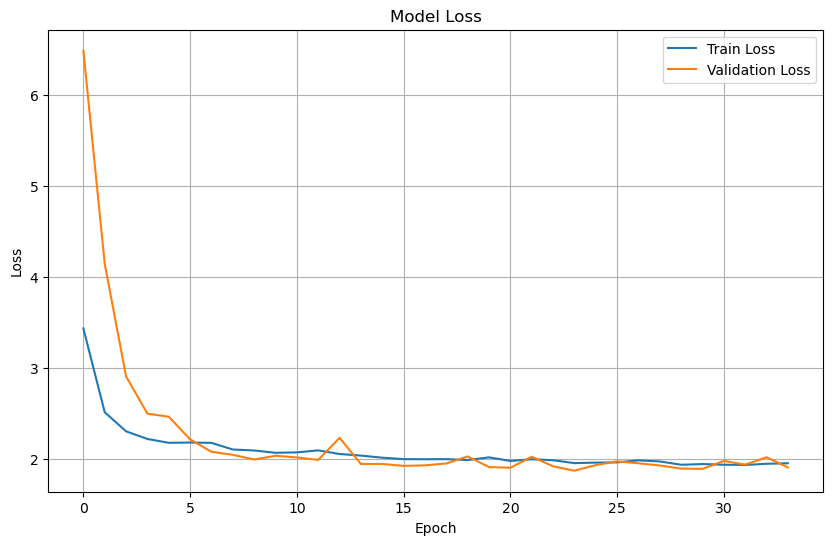

In [98]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

## Prepare test dataset

In [185]:
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_dataset = test_dataset.batch(4)

# Evaluate the model on the test dataset
test_loss, test_mae = model.evaluate(test_dataset)
print(f"Test Loss: {test_loss}")
print(f"Test MAE: {test_mae}")

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 1.0107 - masked_mae: 0.9971
Test Loss: 1.0047893524169922
Test MAE: 0.9370224475860596


## Make some maps of our predictions

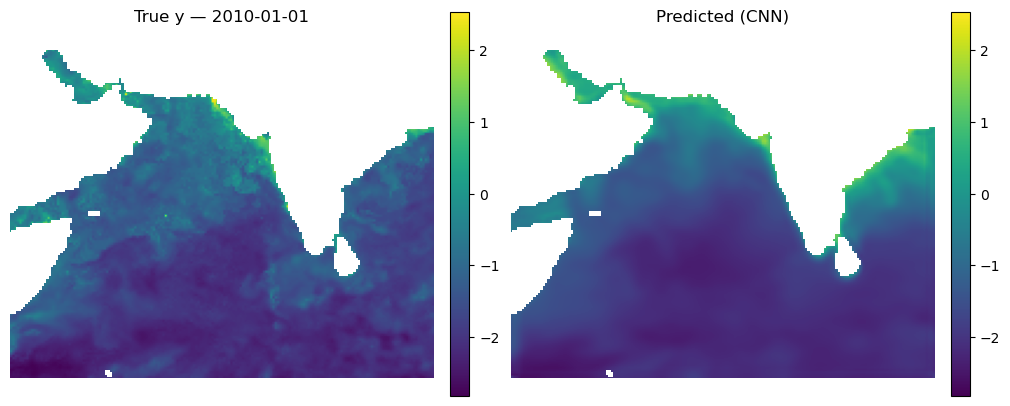

In [111]:
_ = mu.predict_and_plot_date(
    data_xr=dataset,
    date="2010-01-01",
    model=model,
    num_var=cnn_num_var,
    cat_var=cnn_cat_var,
    X_mean=X_mean, X_std=X_std,
    model_type="cnn",
    use_percentiles=False
)

### Let's look at all the months

This is a function that takes our model, the normalizing `X_mean` and `X_std`, the year to use and then makes plots of true versus predicted for the first available day each month. We need to use `X_mean` and `X_std` from our training data. This was returned by `time_series_split()` above. 

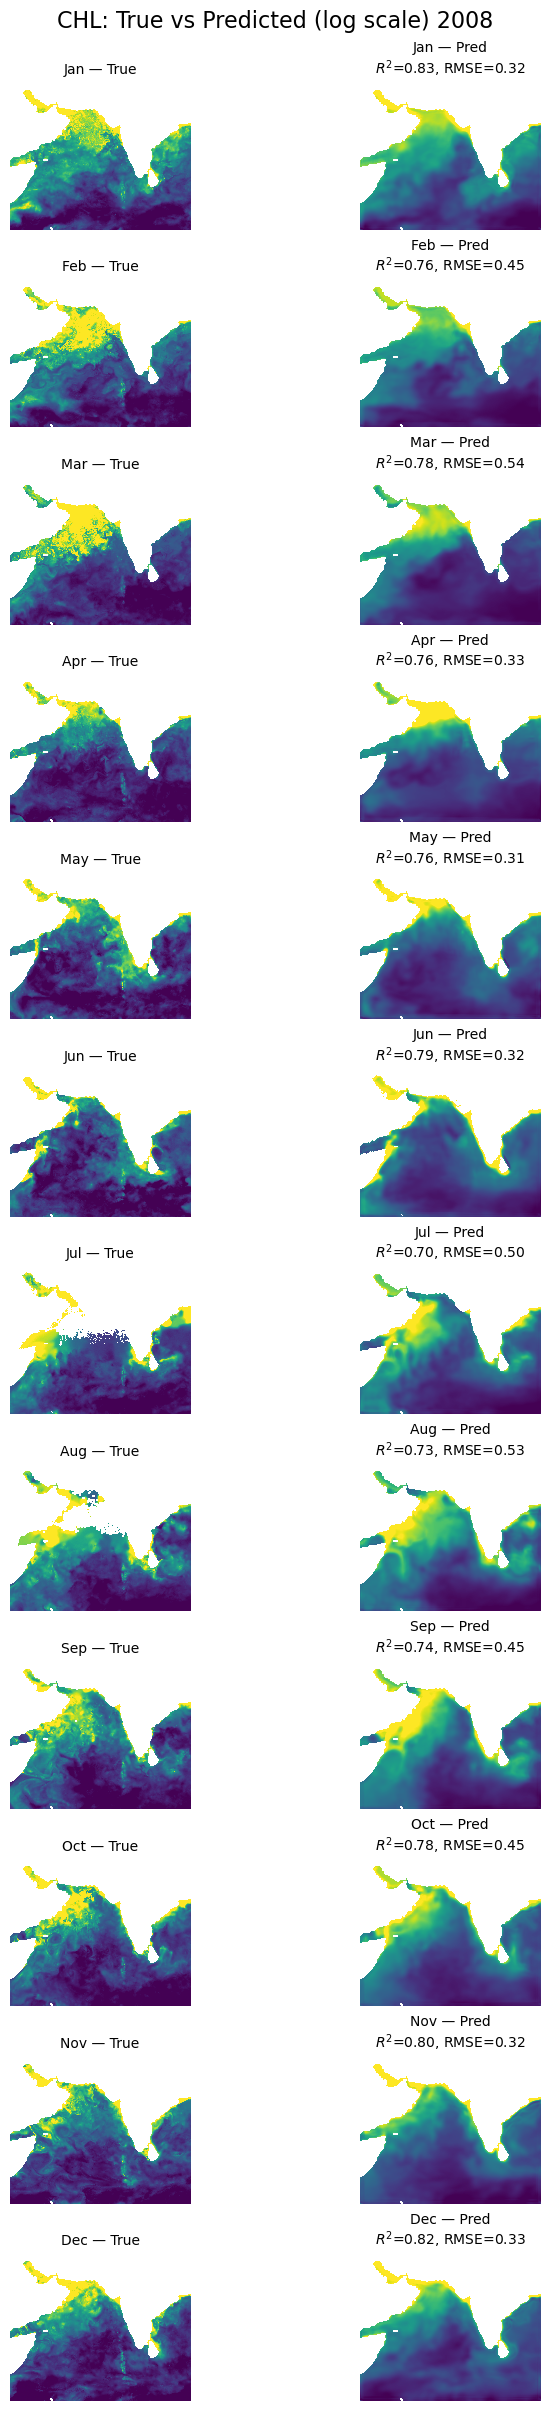

In [112]:
mu.plot_true_vs_predicted_year(dataset, "2008", model, X_mean, X_std, cnn_num_var, cnn_cat_var, y_var="y")

## Look at fit metrics over years

Start by creating a function.

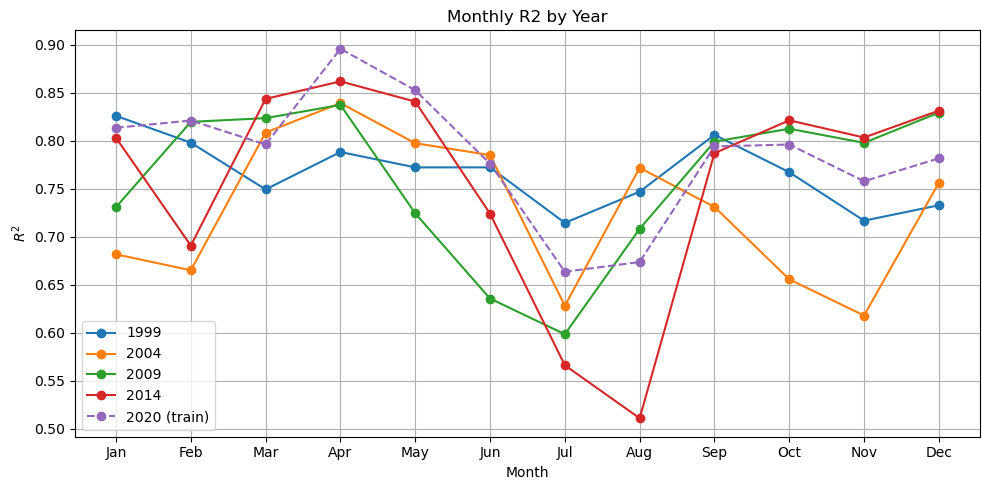

In [113]:
mu.plot_metric_by_month(dataset, ['1999', '2004', '2009', '2014', '2020'], 
                     model, X_mean, X_std, cnn_num_var, cnn_cat_var, training_year="2020")

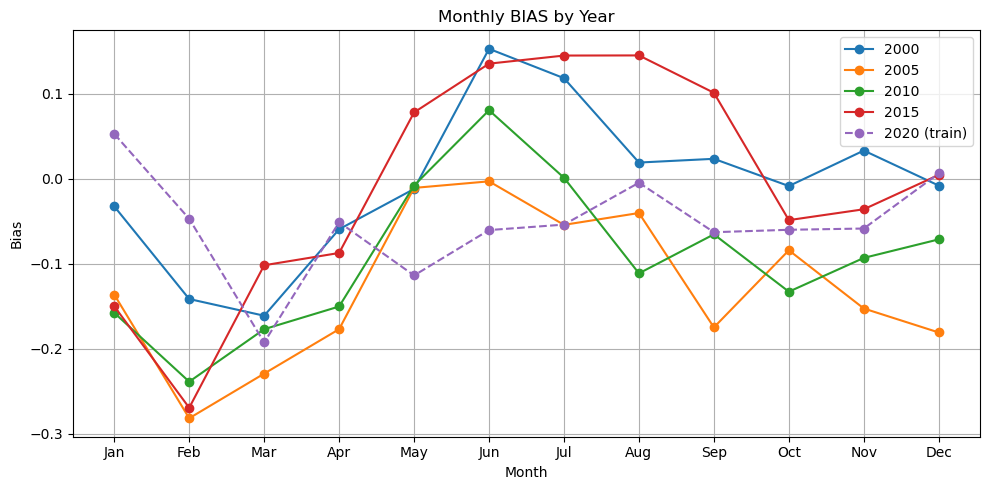

In [189]:
plot_metric_by_month(dataset, ['2000', '2005', '2010', '2015', '2020'], 
                     model, X_mean, X_std, num_var, cat_var, training_year="2020", metric="bias")

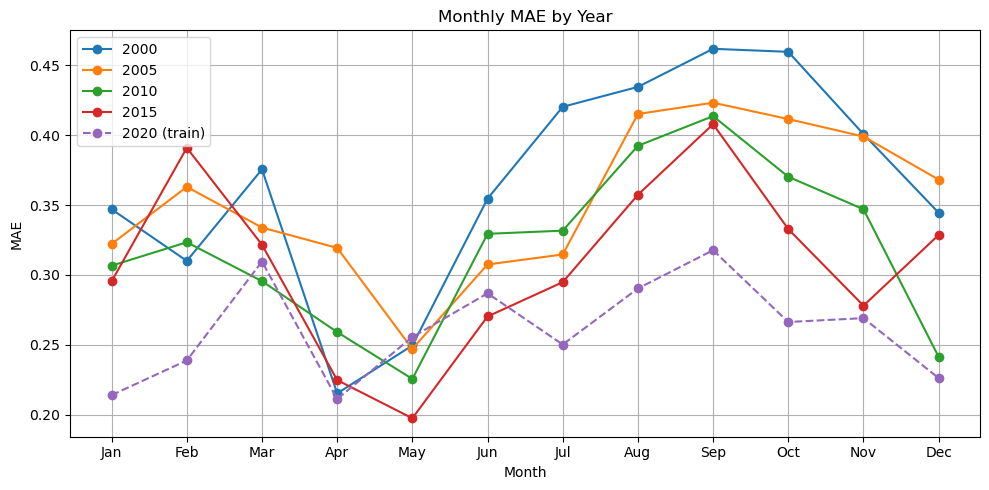

In [191]:
plot_metric_by_month(dataset, ['2000', '2005', '2010', '2015', '2020'], 
                     model, X_mean, X_std, num_var, cat_var, training_year="2020", metric="mae")

SSIM/MS-SSIM run from (about) 0 to 1. Higher is better; 1.0 = identical. Rough, practical bands:

* ≥ 0.95 — near-indistinguishable (often called “visually lossless” in imaging)
* 0.90–0.95 — very good structural agreement
* 0.80–0.90 — clearly similar patterns, some blur/offset/contrast differences
* **0.60–0.80 — moderate; big structures align but details differ**
* < 0.60 — poor structural match

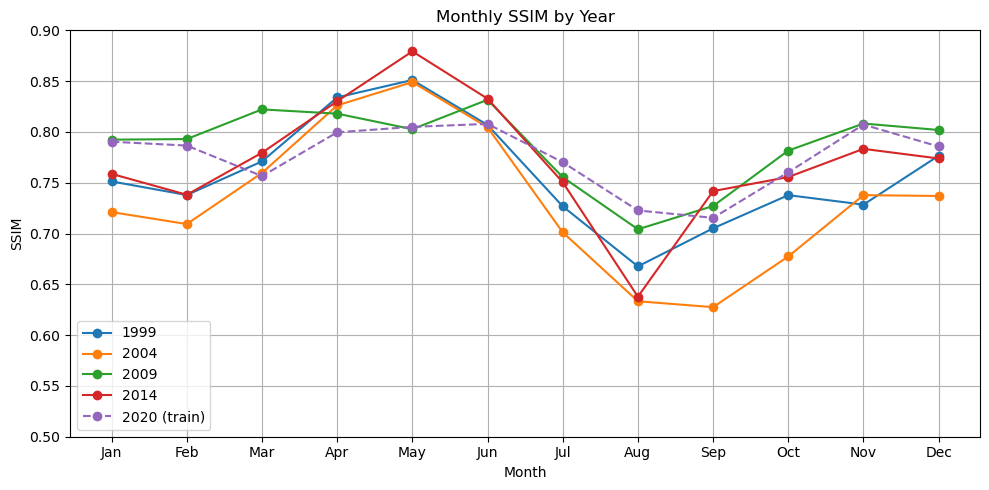

In [101]:
mu.plot_metric_by_month(dataset, ['1999', '2004', '2009', '2014', '2020'], 
                     model, X_mean, X_std, cnn_num_var, cnn_cat_var, training_year="2020", metric="ssim", ymin=0.5, ymax=0.9)

## Compare to a BRT

We will use exactly the same explanatory variables. The main difference is that the BRT does not learn local features, like fronts and edges. On the otherhand, it doesn't have the CNNs tendency to smudge out (average) local patterns.

In [114]:
# Fit the model
brt, brt_model = mu.train_brt_from_splits(
    X_train, y_train, feature_names=cnn_num_var + cnn_cat_var,
    grid_shape=(dataset.sizes['lat'], dataset.sizes['lon'])
)

## Look a fit metrics

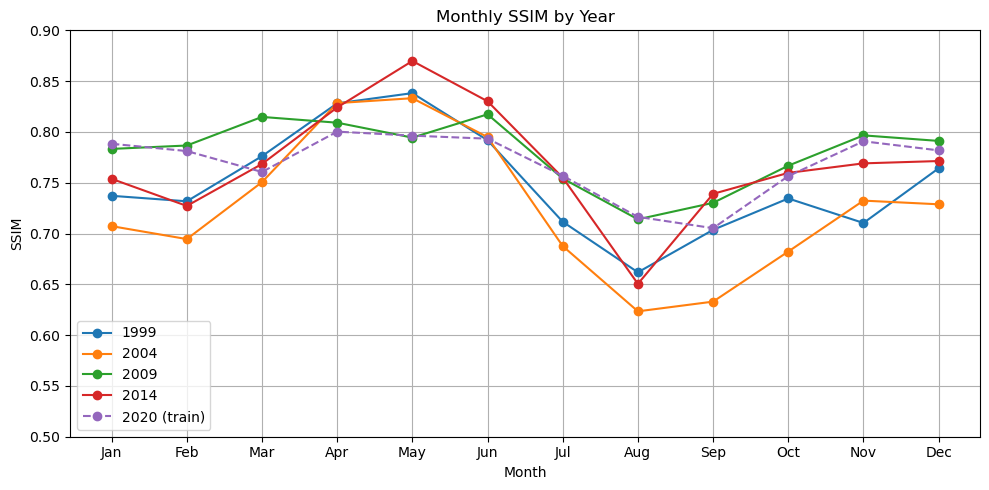

In [115]:
# Compare monthly R² / RMSE / SSIM:
mu.plot_metric_by_month(dataset, ['1999', '2004', '2009', '2014', '2020'], 
                    brt_model, X_mean, X_std, 
                    cnn_num_var, cnn_cat_var, training_year="2020", metric="ssim", ymin=0.5, ymax=0.9)

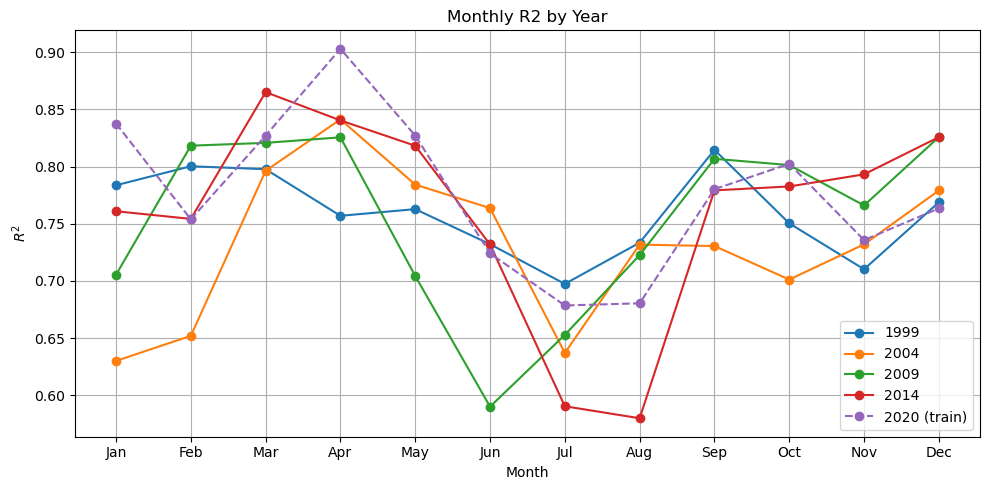

In [50]:
# Compare monthly R² / RMSE / SSIM:
mu.plot_metric_by_month(dataset, ['1999', '2004', '2009', '2014', '2020'],
                     brt_model, X_mean, X_std, cnn_num_var, cnn_cat_var,
                     training_year="2020", metric="r2")

## Make some plots

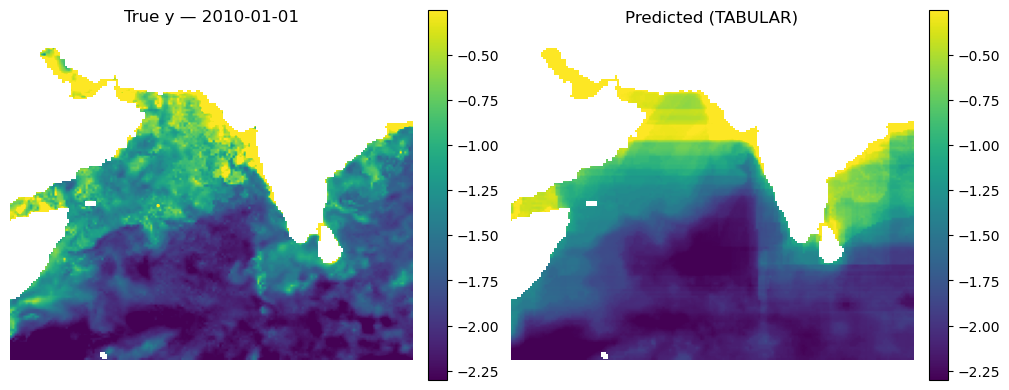

In [48]:
_ = mu.predict_and_plot_date(
    data_xr=dataset,
    date="2010-01-01",
    model=brt_model,
    num_var=cnn_num_var,
    cat_var=cnn_cat_var,
    X_mean=X_mean, X_std=X_std,
    model_type="tabular",
    use_percentiles=True
)

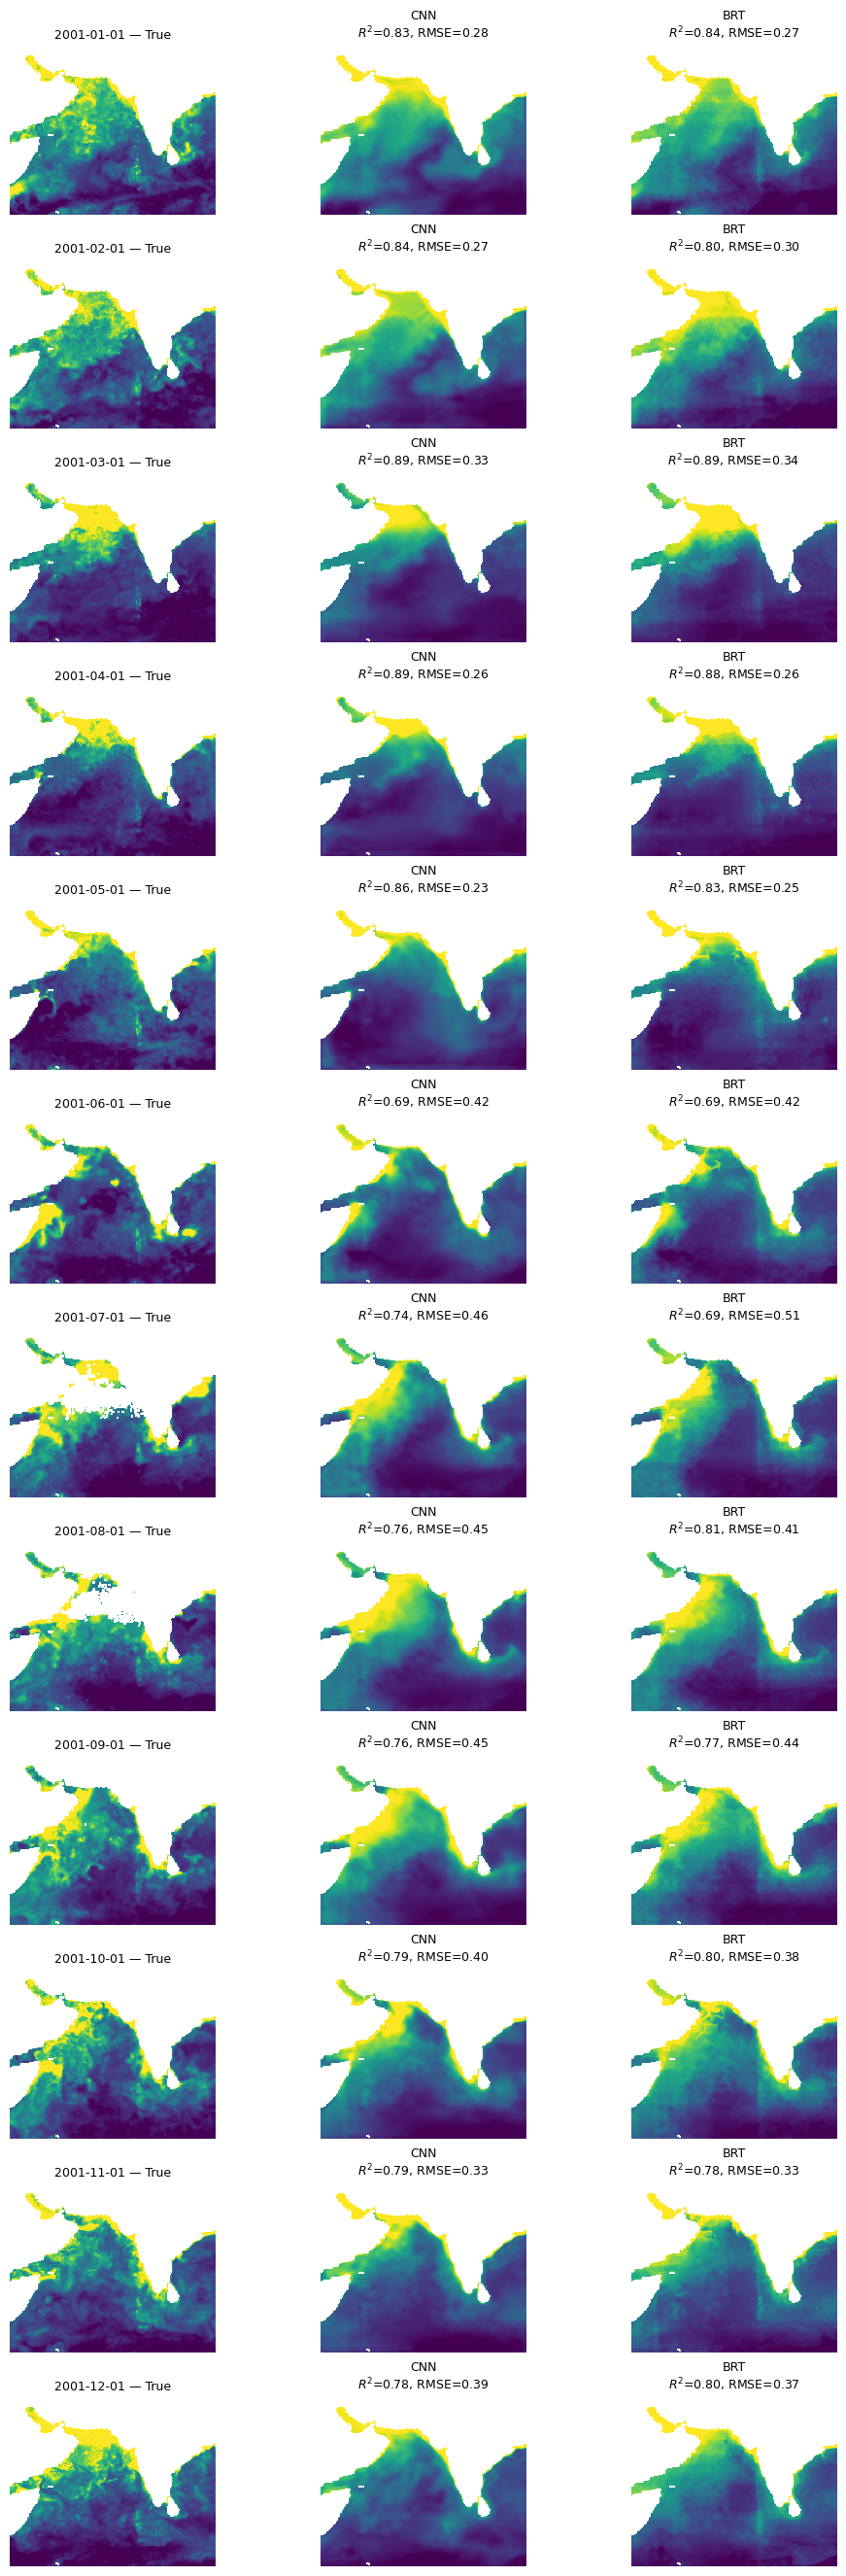

In [116]:
mu.plot_true_vs_predicted_year_multi(
    dataset, "2001", [model, brt_model], X_mean, X_std, 
    cnn_num_var, cnn_cat_var, y_var="y",
    model_types=["cnn", "tabular"],
    model_names=["CNN", "BRT"])

## Summary

Now we have a model that is doing ok. It still doesn't pick up the upwelling zone at the southern tip of India too well however. There is something about that area that is different and that the model is unable to learn. We should look into what drives that upwelling zone. It maybe that the relationship between SST and salinity are different there. It pokes down into a strong E-W current system.

Also the out of training years shows big variation in performance by season which suggests that we need to train on more years (more seasons).

We used the full region as the input shape for learning. What might have happened is that the model learned where and when in the region CHL tends to be high and low. But it might not have used SST and salinity at all and it might, therefore, have a hard time generalizing to other years. Note it is unlikely that this model would generalize to other regions as the SST and salinity associations are very specific to the oceanography and ocean biochemistry of the region.  

## Functions

Save to `utils.py` and load.

In [80]:
import numpy as np
import pandas as pd
import xarray as xr

def count_valid_days_by_month(
    ds: xr.Dataset,
    year,
    vars_to_check=("y",),          # str or iterable of str
    mask_var="ocean_mask",         # 1=ocean, 0=land
    nan_max_frac=0.05,             # allow ≤ 5% NaNs over ocean
):
    """
    Return a Series with counts of days per month that pass the NaN filter.
    A day passes iff, for every variable in `vars_to_check`, the number of
    NaNs over the ocean is <= nan_max_frac * ocean_pixels_on_that_day.
    """
    # subset to the year
    dsy = ds.sel(time=str(year))

    # tidy inputs
    if isinstance(vars_to_check, str):
        vars_to_check = [vars_to_check]

    # spatial mask, broadcast to (time, lat, lon)
    ocean = dsy[mask_var].astype(bool)
    if "time" not in ocean.dims:
        ocean = ocean.expand_dims(time=dsy["time"])
    # broadcast to the target grid (uses first var as template)
    template = dsy[vars_to_check[0]] if vars_to_check else dsy["y"]
    ocean = ocean.broadcast_like(template)

    # how many ocean pixels each day?
    spatial_dims = [d for d in ocean.dims if d != "time"]
    ocean_count = ocean.sum(dim=spatial_dims)  # (time,)
    nan_thresh_t = nan_max_frac * ocean_count  # per time-step threshold

    # build per-var validity (True if NaN count over ocean <= threshold)
    valid_per_var = []
    for v in vars_to_check:
        if v not in dsy:
            raise KeyError(f"Variable '{v}' not in dataset.")
        arr = dsy[v]
        if "time" not in arr.dims:
            arr = arr.expand_dims(time=dsy["time"])
        arr = arr.broadcast_like(ocean)
        v_nan = xr.apply_ufunc(np.isnan, arr) & ocean
        v_nan_count = v_nan.sum(dim=spatial_dims)  # (time,)
        valid_per_var.append(v_nan_count <= nan_thresh_t)

    # day is valid if all vars pass
    valid_all = xr.concat(valid_per_var, dim="var").all(dim="var")  # (time,) bool

    # group by month and count
    month_idx = pd.to_datetime(valid_all["time"].values).month
    counts = pd.Series(valid_all.values, index=month_idx).groupby(level=0).sum().astype(int)
    # ensure all months present
    counts = counts.reindex(range(1,13), fill_value=0)
    counts.index.name = "month"
    counts.name = f"valid_days_{year}"
    return counts


In [89]:
# Count days per month in 2020 where y has ≤5% NaNs over ocean
c1 = count_valid_days_by_month(dataset, 2010, vars_to_check="y", nan_max_frac=0.08)
print(c1)

month
1     31
2     28
3     31
4     30
5     31
6     30
7     12
8     29
9     30
10    31
11    30
12    31
Name: valid_days_2010, dtype: int64
